# Industrial Sensor Failure Detection Model

In [228]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


In [229]:
df = pd.read_csv('F:\Prediction\industrial_sensor_anomaly_dataset_100k.csv')

# EDA

In [230]:
df.shape

(100000, 7)

In [231]:
df.isnull().sum()

timestamp                0
sensor_temperature       0
sensor_pressure          0
sensor_vibration         0
sensor_voltage           0
sensor_rotation_speed    0
anomaly_label            0
dtype: int64

In [232]:
df.columns

Index(['timestamp', 'sensor_temperature', 'sensor_pressure',
       'sensor_vibration', 'sensor_voltage', 'sensor_rotation_speed',
       'anomaly_label'],
      dtype='object')

In [233]:
df1 = df.drop(columns=['anomaly_label'], axis=1)

In [234]:
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

In [235]:
df['timestamp'].min(),df['timestamp'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-03-10 10:39:00'))

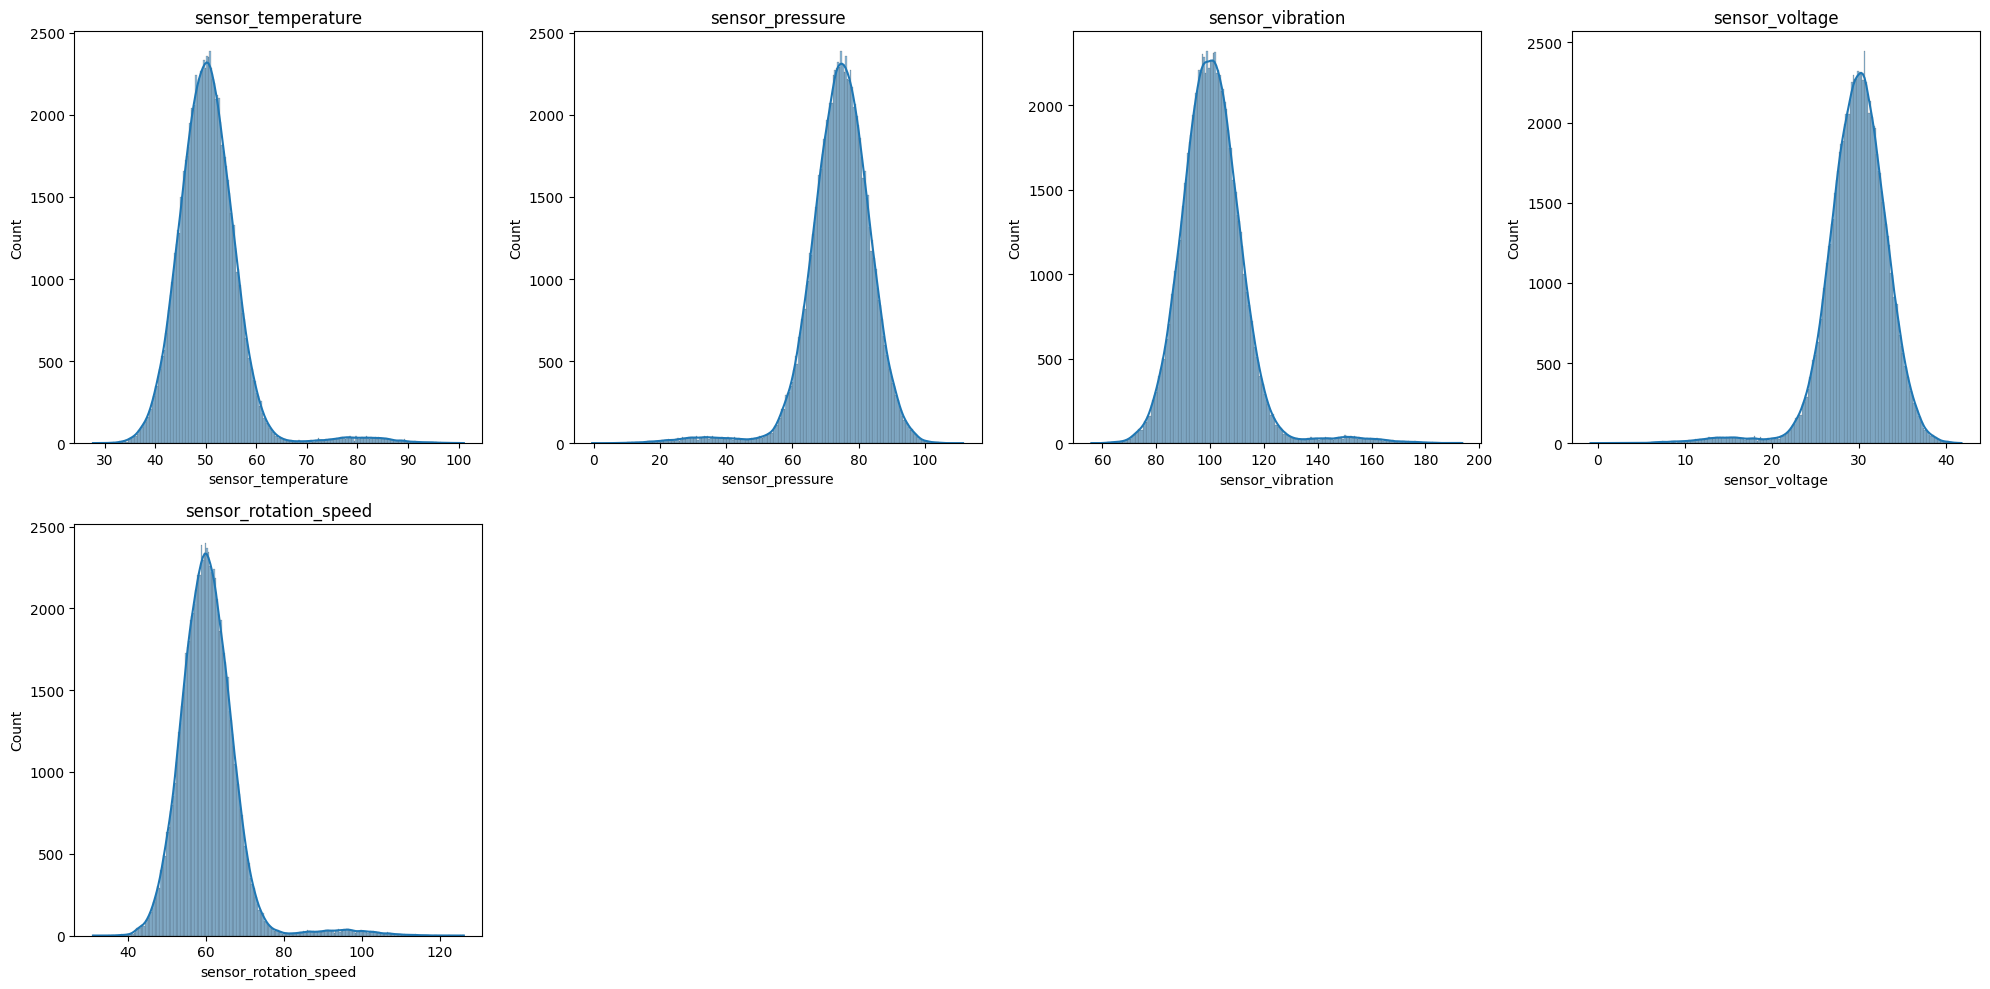

In [236]:
cols = df1.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, 5*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df1[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

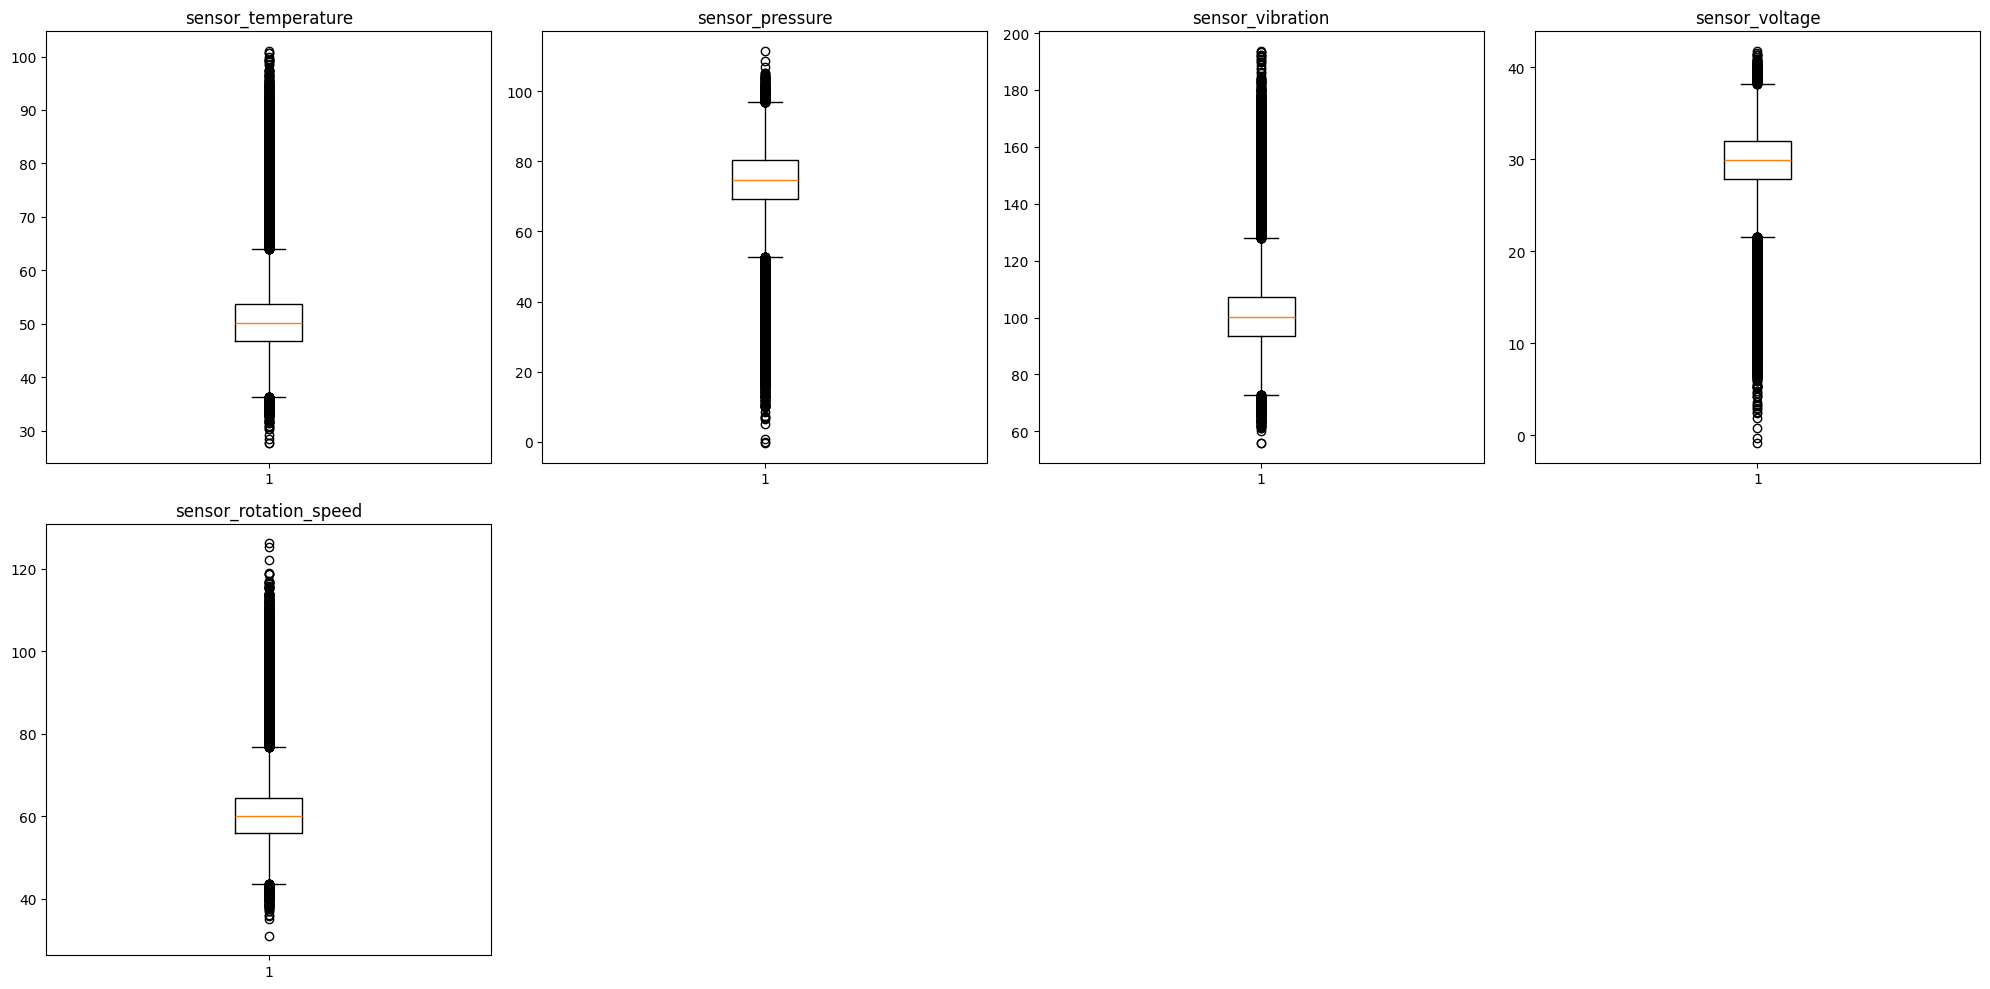

In [237]:
cols = df1.select_dtypes(include=['int64','float64']).columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df1[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

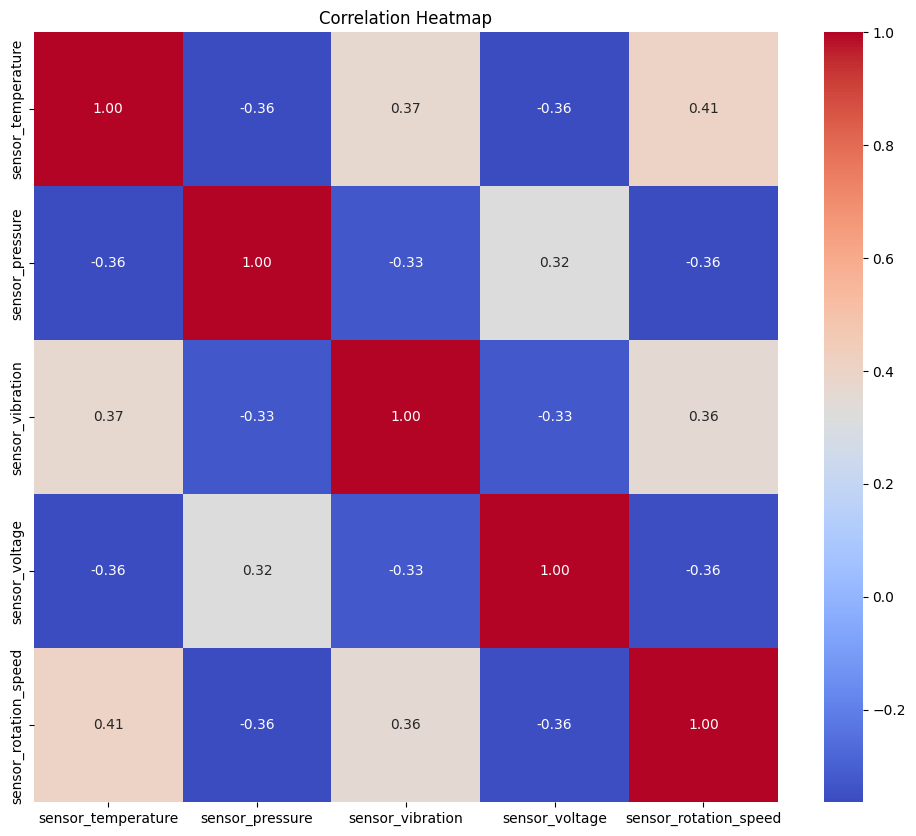

In [238]:
corr = df1.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [239]:
df = df.drop("timestamp", axis=1)

X = df.drop("anomaly_label", axis=1)
y = df["anomaly_label"]

In [240]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest Approach

In [241]:
iso_model = IsolationForest(contamination=0.02, random_state=42)

iso_model.fit(X_scaled)

iso_pred = iso_model.predict(X_scaled)

iso_pred = np.where(iso_pred == -1, 1, 0)

In [242]:
print("Isolation Forest Results :")

print("Precision:", precision_score(y, iso_pred))
print("Recall:", recall_score(y, iso_pred))
print("F1 Score:", f1_score(y, iso_pred))

Isolation Forest Results :
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [243]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, iso_pred)

tn, fp, fn, tp = cm.ravel()

print("Total False Alarms (False Positives):", fp)

Total False Alarms (False Positives): 0


In [244]:
df["predicted_anomaly"] = iso_pred

alerts = df[df["predicted_anomaly"] == 1]

print("Detected Failures:", alerts.shape[0])

Detected Failures: 2000


In [245]:
false_alarms = df[(df["predicted_anomaly"] == 1) & (df["anomaly_label"] == 0)]

print("Total False Alarms:", false_alarms.shape[0])

Total False Alarms: 0


In [246]:
print("Isolation Forest Results : ")
print("Total Alarms Raised:", sum(iso_pred))
print("Correct Alarms (TP):", tp)
print("False Alarms (FP):", fp)
print("Missed Alarms (FN):", fn)

Isolation Forest Results : 
Total Alarms Raised: 2000
Correct Alarms (TP): 2000
False Alarms (FP): 0
Missed Alarms (FN): 0


# PCA Approach

In [248]:
healthy_df = df[df["anomaly_label"] == 0]

X_train = healthy_df.drop(["anomaly_label"], axis=1)

X_test = df.drop(["anomaly_label"], axis=1)

y_test = df["anomaly_label"]

In [249]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [250]:
from sklearn.decomposition import PCA

pca = PCA(0.95)

pca.fit(X_train_scaled)

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [251]:
X_test_pca = pca.transform(X_test_scaled)

X_reconstructed = pca.inverse_transform(X_test_pca)

error = ((X_test_scaled - X_reconstructed) ** 2).mean(axis=1)

In [252]:
train_pca = pca.transform(X_train_scaled)

train_recon = pca.inverse_transform(train_pca)

train_error = ((X_train_scaled - train_recon) ** 2).mean(axis=1)

threshold = np.percentile(train_error, 99)

In [253]:
pca_pred = (error > threshold).astype(int)

In [254]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("PCA Results : ")
print("Precision:", precision_score(y_test, pca_pred))
print("Recall:", recall_score(y_test, pca_pred))
print("F1 Score:", f1_score(y_test, pca_pred))

PCA Results : 
Precision: 0.671366230278617
Recall: 1.0
F1 Score: 0.8033741715203856


In [255]:
cm = confusion_matrix(y_test, pca_pred)

TN, FP, FN, TP = cm.ravel()

total_failures = TP + FN
failures_identified = TP
failures_missed = FN
false_alarms = FP

print("Total failures present:", total_failures)
print("Failures identified:", failures_identified)
print("Failures missed:", failures_missed)
print("False alarms generated:", false_alarms)

Total failures present: 2000
Failures identified: 2000
Failures missed: 0
False alarms generated: 979


In [256]:
total_alerts = TP + FP

print("Total alerts generated:", total_alerts)

Total alerts generated: 2979


In [257]:
print("\n----- Anomaly Detection Summary PCA Approach -----")

print("Total Data Points:", len(y_test))
print("Total Failures Present:", TP + FN)
print("Failures Detected:", TP)
print("Failures Missed:", FN)
print("False Alarms:", FP)
print("Correct Normal Predictions:", TN)
print("Total Alerts Generated:", TP + FP)


----- Anomaly Detection Summary PCA Approach -----
Total Data Points: 100000
Total Failures Present: 2000
Failures Detected: 2000
Failures Missed: 0
False Alarms: 979
Correct Normal Predictions: 97021
Total Alerts Generated: 2979


# Autoencoders Approach

In [258]:
X = df.drop(columns=['anomaly_label'])
y = df['anomaly_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [259]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [260]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dense(8, activation='relu')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

In [261]:
X_train_normal = X_train[y_train == 0]

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


1103/1103 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0108 - val_loss: 2.2844e-04
Epoch 2/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 9.7834e-04 - val_loss: 0.0044
Epoch 3/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.5792e-04 - val_loss: 4.0472e-04
Epoch 4/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.8857e-04 - val_loss: 0.0013
Epoch 5/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 5.1479e-04
Epoch 6/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 7.7009e-04 - val_loss: 9.7449e-04
Epoch 7/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.5314e-04 - val_loss: 9.6730e-04
Epoch 8/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.8567e-04 - val_loss: 2.3036e-04
Epoch 9/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.1268e-04 - val_loss: 4.1637e-04
Epoch 10/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 7.7952e-04 - val_loss: 0.0010
Epoch 11/20
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.9915e

In [262]:
X_test_pred = autoencoder.predict(X_test)

mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step


In [263]:
threshold = np.percentile(mse, 95)   
y_pred = (mse > threshold).astype(int)

In [264]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Autoencoder Results:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Autoencoder Results:
Precision: 0.413
Recall: 1.0
F1 Score: 0.5845718329794763


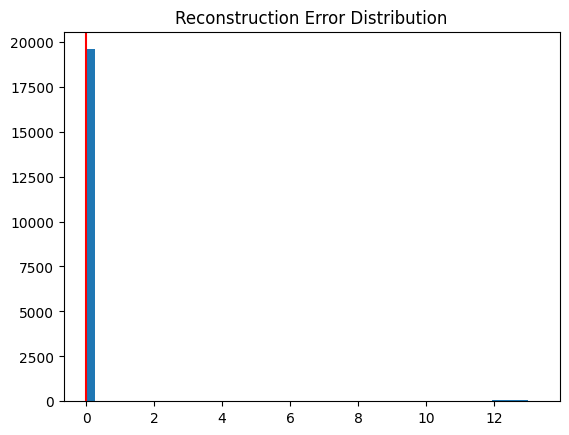

In [265]:
plt.hist(mse, bins=50)
plt.axvline(threshold, color='red')
plt.title("Reconstruction Error Distribution")
plt.show()

In [266]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[19000   587]
 [    0   413]]


In [267]:
tn, fp, fn, tp = cm.ravel()
print("Autoencoders Results :")
print("True Positives (Correct Alarms Detected):", tp)
print("False Negatives (Missed Alarms):", fn)
print("False Positives (False Alarms):", fp)
print("True Negatives (Correct Normal):", tn)

Autoencoders Results :
True Positives (Correct Alarms Detected): 413
False Negatives (Missed Alarms): 0
False Positives (False Alarms): 587
True Negatives (Correct Normal): 19000
